The boundary conditions are initialized with arrays 
 [[ 0.         -0.         -0.         -0.         -0.         -0.
  -0.         -0.         -0.         -0.         -0.          0.        ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.15691819]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.46689073]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.76536686]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          1.04499713]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          1.2988961 ]
 [ 0.          0.          0.          0.          0.          0.
   0.          0.          0.     

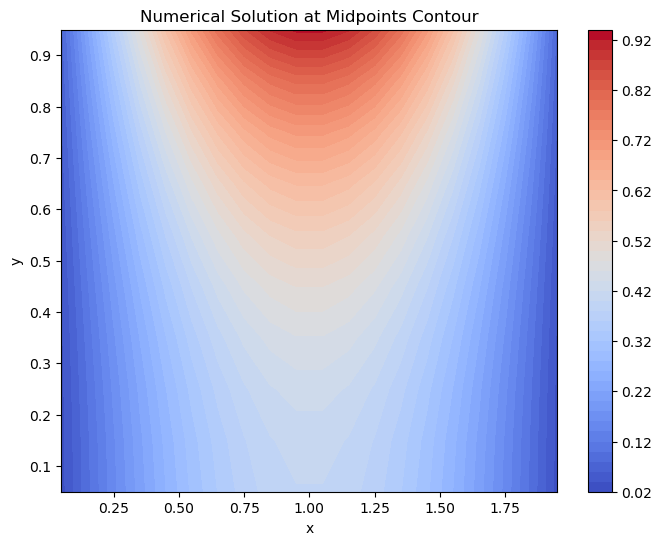

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
Lx, Ly = 2.0, 1.0
nx, ny = 20,10
dx, dy = Lx / nx, Ly / ny
tolerance = 1e-10

# Initialize temperature array including ghost cells
T = np.zeros((nx + 2, ny + 2))

# Function to set boundary conditions
def set_boundary_conditions(T, nx, ny, dx, dy):
    for i in range(1, nx + 1):  # Top boundary (y = 1)
        x = (i - 0.5) * dx
        T[i, ny + 1] = 2 * np.sin(np.pi * x / 2) - T[i, ny]

    for i in range(1, nx + 1):  # Bottom boundary (y = 0)
        T[i, 0] = T[i, 1]

    for j in range(1, ny + 1):  # Left boundary (x = 0)
        T[0, j] = -T[1, j]

    for j in range(1, ny + 1):  # Right boundary (x = Lx)
        T[nx + 1, j] = -T[nx, j]

    return T
print(f"The boundary conditions are initialized with arrays \n {set_boundary_conditions(T, nx, ny, dx, dy)}")

# Gauss-Seidel iteration function
def gauss_seidel_iteration(T, nx, ny):
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            T[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
    return T

# L2 norm calculation
def L2_normalization(T, old_T, nx, ny):
    diff = T[1:nx+1, 1:ny+1] - old_T[1:nx+1, 1:ny+1]
    return np.sqrt(np.sum(diff**2)/(nx*ny))


# Apply boundary conditions
T = set_boundary_conditions(T, nx, ny, dx, dy)

# Iterative solution with Gauss-Seidel
iteration = 0
L2_norm = 1e10
while L2_norm > tolerance:
    old_T = T.copy()
    T = gauss_seidel_iteration(T, nx, ny)
    T = set_boundary_conditions(T, nx, ny, dx, dy)  # Reapply boundary conditions
    L2_norm = L2_normalization(T, old_T, nx, ny)
    iteration += 1
print(f"Solution converged after {iteration} number of iterations")
print(f"The Value of the L2 norm is {L2_norm}")


# Plotting function
def plot_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Numerical Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_solution_midpoints(T, nx, ny, dx, dy)

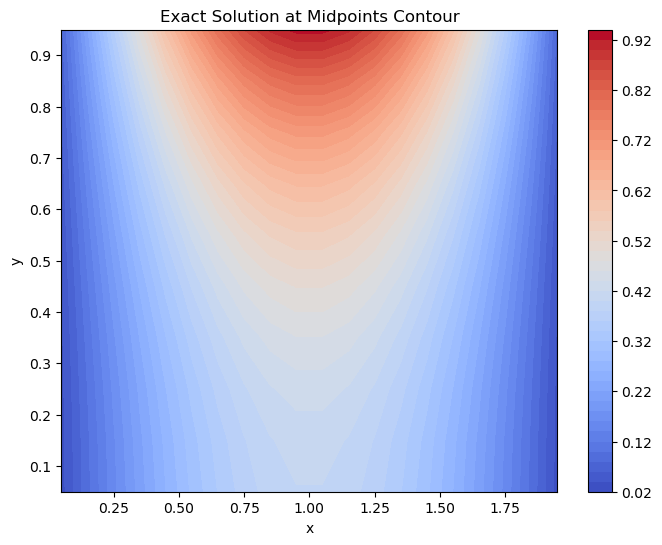

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters for the grid
Lx, Ly = 2.0, 1.0
nx, ny = 20,10
dx, dy = Lx / nx, Ly / ny

# Function to compute the exact solution at cell centers
def exact_solution(nx, ny, dx, dy):
    T_exact = np.zeros((nx + 2, ny + 2))
    for i in range(1, nx + 1):
        for j in range(1, ny + 1):
            x = (i - 0.5) * dx
            y = (j - 0.5) * dy
            T_exact[i, j] = (np.sin(np.pi * x / 2) *
                             np.cosh(np.pi * y / 2) /
                             np.cosh(np.pi / 2))
    return T_exact

# Compute the exact solution
T_exact = exact_solution(nx, ny, dx, dy)

def plot_exact_solution_midpoints(T, nx, ny, dx, dy):
    x = np.linspace(dx / 2, Lx - dx / 2, nx)  # Midpoints along x
    y = np.linspace(dy / 2, Ly - dy / 2, ny)  # Midpoints along y
    X, Y = np.meshgrid(x, y)

    # Extract the interior points (excluding ghost cells)
    T_midpoints = T[1:nx + 1, 1:ny + 1]

    plt.figure(figsize=(8, 6))
    contour = plt.contourf(X, Y, T_midpoints.T, levels=50, cmap='coolwarm') 
    plt.colorbar(contour)  # Add color bar
    plt.title("Exact Solution at Midpoints Contour")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_exact_solution_midpoints(T_exact, nx, ny, dx, dy)

## L2 Norm Error

In [5]:
def L2_Norm_Error(T,T_exact):
    diff = T[1:nx+1, 1:ny+1] - T_exact[1:nx+1, 1:ny+1]
    # Calculate the L2 norm error
    L2_norm_error = np.sqrt(np.sum(diff**2) / (nx * ny))
    return L2_norm_error
L2_Norm_Error(T,T_exact)

np.float64(0.0008832988121117865)

In [6]:
print(f"The values of the temperature at cell centers calculated numerically: \n {T}")
print(f"The values of the temperature at cell centers calculated with the exact solution: \n {T_exact}")

The values of the temperature at cell centers calculated numerically: 
 [[ 0.         -0.03136129 -0.03213351 -0.03369696 -0.03609014 -0.03937199
  -0.0436233  -0.04894876 -0.05547951 -0.06337634 -0.07283371  0.        ]
 [ 0.03136129  0.03136129  0.03213351  0.03369696  0.03609014  0.03937199
   0.0436233   0.04894876  0.05547951  0.06337634  0.07283371  0.08408448]
 [ 0.09331165  0.09331165  0.09560929  0.10026115  0.10738178  0.11714649
   0.12979575  0.14564101  0.16507243  0.18856848  0.21670772  0.25018301]
 [ 0.15296437  0.15296437  0.15673086  0.16435658  0.17602931  0.19203647
   0.2127722   0.23874708  0.27060072  0.30911744  0.35524566  0.41012121]
 [ 0.20885059  0.20885059  0.21399319  0.22440501  0.24034242  0.26219786
   0.29050949  0.32597442  0.36946592  0.4220549   0.48503628  0.55996085]
 [ 0.25959423  0.25959423  0.2659863   0.27892783  0.2987375   0.32590308
   0.36109347  0.40517518  0.45923365  0.52459997  0.60288369  0.69601241]
 [ 0.30394579  0.30394579  0.31142